# Component-based SMS-EMOA: configuration examples

This notebook illustrates `jmetal.component`'s component-based SMS-EMOA (`build_smsemoa()`) across
the configurations exercised by this project's tests and examples under `examples/component/`:

1. Default settings on ZDT4
2. Default settings on DTLZ1
3. Default settings on DTLZ3
4. An unbounded external archive on DTLZ3
5. The observer pattern: watching a front evolve

SMS-EMOA is very similar to NSGA-II (see
[`notebooks/NSGAIIComponentBased.ipynb`](NSGAIIComponentBased.ipynb)): same six-component
`EvolutionaryAlgorithm` template, same factory-function pattern. It differs only in mating
selection (`RandomSelection` rather than tournament) and replacement (`SMSEMOAReplacement`, which
prunes the worst non-dominated front by hypervolume contribution rather than by ranking and
crowding distance). Unlike NSGA-II, there is no `offspring_population_size` parameter -- SMS-EMOA
is steady-state by definition and always produces exactly one offspring per generation.

`build_smsemoa()` has been verified to produce results identical to the classic
`jmetal.algorithm.multiobjective.smsemoa.SMSEMOA` for a fixed seed, both on small settings
(`tests/component/algorithm/multiobjective/test_smsemoa_equivalence.py`) and at the full-scale
settings used in this notebook (identical final populations and quality indicator values across 5
seeds on ZDT4, DTLZ1 and DTLZ2).

Each section shows the final front against its reference front and reports three quality
indicators: hypervolume, IGD+, and the additive epsilon indicator (the last two delegate to
[moocore](https://multi-objective.github.io/moocore/python/) for the actual computation).

See [`docs/advanced-topics/component-architecture.md`](../docs/advanced-topics/component-architecture.md)
for the full picture of this architecture.


In [1]:
import random

import numpy as np
import matplotlib.pyplot as plt

from jmetal.component.algorithm.multiobjective.smsemoa import build_smsemoa
from jmetal.component.catalogue.common.termination import TerminationByEvaluations
from jmetal.core.quality_indicator import (
    AdditiveEpsilonIndicator,
    HyperVolume,
    InvertedGenerationalDistancePlus,
)
from jmetal.lab.visualization import Plot
from jmetal.operator.crossover import SBXCrossover
from jmetal.operator.mutation import PolynomialMutation
from jmetal.problem import DTLZ1, DTLZ3, ZDT4
from jmetal.util.archive import NonDominatedSolutionsArchive
from jmetal.util.solution import get_non_dominated_solutions, read_solutions


### A small helper to report indicator values

Each section below builds a front, then compares it against the problem's reference front using
three indicators. This helper keeps that repeated bit of code in one place.


In [2]:
def report_indicators(front, reference_solutions, reference_point):
    front_array = np.array([solution.objectives for solution in front])
    reference_array = np.array([solution.objectives for solution in reference_solutions])

    hypervolume = HyperVolume(reference_point=reference_point)
    igd_plus = InvertedGenerationalDistancePlus(reference_array)
    epsilon = AdditiveEpsilonIndicator(reference_array)

    print(f"Front size:        {len(front)}")
    print(f"Hypervolume:       {hypervolume.compute(front_array):.4f}")
    print(f"IGD+:              {igd_plus.compute(front_array):.4f}")
    print(f"Additive epsilon:  {epsilon.compute(front_array):.4f}")


## 1. Default settings on ZDT4

`build_smsemoa()` only requires the problem, the population size, and the crossover/mutation
operators; every other component (selection, variation, replacement, termination) takes
SMS-EMOA's standard configuration unless overridden. ZDT4 is multi-modal (many local Pareto
fronts) -- SMS-EMOA's steady-state, elitist replacement (on each generation it only ever discards
the single worst-hypervolume-contributing solution of the worst non-dominated front) makes it
comparatively robust here: across 5 arbitrary seeds tested during development, every run reached
the full `f1 ∈ [0, 1]` range, with none of the seed-picking this project's NSGA-II notebook needed
for the same problem. See
[`examples/component/smsemoa_default_zdt4.py`](../examples/component/smsemoa_default_zdt4.py).


In [3]:
seed = 1
random.seed(seed)

problem = ZDT4()
reference_front = read_solutions(filename="../resources/reference_fronts/ZDT4.pf")

algorithm = build_smsemoa(
    problem,
    population_size=100,
    crossover=SBXCrossover(probability=1.0, distribution_index=20, rng=np.random.default_rng(seed)),
    mutation=PolynomialMutation(
        probability=1.0 / problem.number_of_variables(),
        distribution_index=20,
        rng=np.random.default_rng(seed),
    ),
    termination=TerminationByEvaluations(max_evaluations=25000),
    rng=np.random.default_rng(seed),
)
algorithm.run()

front = get_non_dominated_solutions(algorithm.result())
print(f"Computing time: {algorithm.total_computing_time:.2f}s")


Computing time: 7.70s


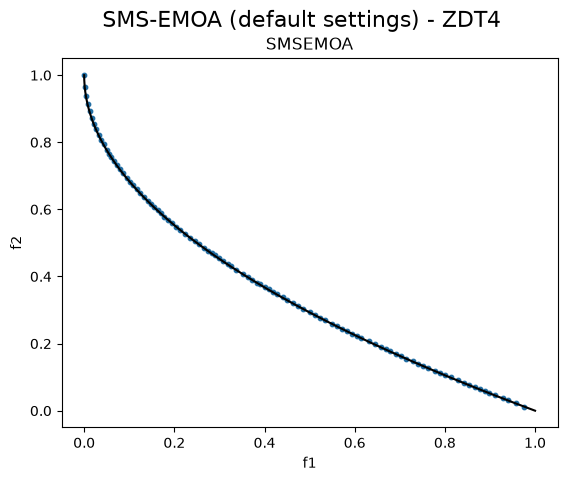

In [4]:
plot_front = Plot(
    title=f"SMS-EMOA (default settings) - {problem.name()}",
    reference_front=reference_front,
    axis_labels=["f1", "f2"],
)
plot_front.plot(front, label=algorithm.get_name())


In [5]:
report_indicators(front, reference_front, reference_point=[1, 1])

Front size:        100
Hypervolume:       0.6612
IGD+:              0.0029
Additive epsilon:  0.0125


## 2. Default settings on DTLZ1

DTLZ1's Pareto front is a flat hyperplane (`f1 + f2 + f3 = 0.5`) reachable through `11^k - 1`
local optima -- a very different front geometry than ZDT4's or DTLZ3's curved fronts, and a good
test of the replacement strategy's ranking on a degenerate front. See
[`examples/component/smsemoa_default_dtlz1.py`](../examples/component/smsemoa_default_dtlz1.py).


In [6]:
seed = 1
random.seed(seed)

problem = DTLZ1()
reference_front = read_solutions(filename="../resources/reference_fronts/DTLZ1.3D.pf")

algorithm = build_smsemoa(
    problem,
    population_size=100,
    crossover=SBXCrossover(probability=1.0, distribution_index=20, rng=np.random.default_rng(seed)),
    mutation=PolynomialMutation(
        probability=1.0 / problem.number_of_variables(),
        distribution_index=20,
        rng=np.random.default_rng(seed),
    ),
    termination=TerminationByEvaluations(max_evaluations=40000),
    rng=np.random.default_rng(seed),
)
algorithm.run()

front = get_non_dominated_solutions(algorithm.result())
print(f"Computing time: {algorithm.total_computing_time:.2f}s")


Computing time: 13.14s


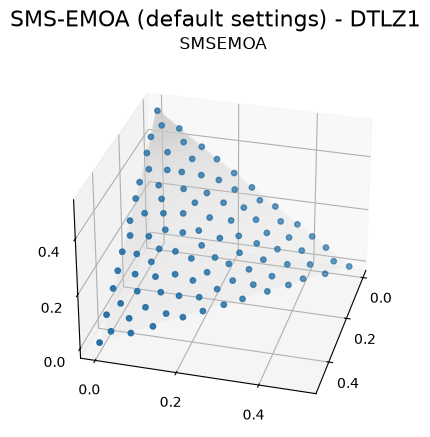

In [7]:
plot_front = Plot(
    title=f"SMS-EMOA (default settings) - {problem.name()}",
    reference_front=reference_front,
    axis_labels=["f1", "f2", "f3"],
)
plot_front.plot(front, label=algorithm.get_name())


In [8]:
report_indicators(front, reference_front, reference_point=[1, 1, 1])

Front size:        100
Hypervolume:       0.9740
IGD+:              0.0134
Additive epsilon:  0.0263


## 3. Default settings on DTLZ3

DTLZ3 shares DTLZ2's spherical Pareto front but its landscape has `3^k - 1` local fronts, making
it a much harder three-objective convergence test at the same evaluation budget -- this is a
known property of DTLZ3 itself (published benchmarks typically use far more than 40000
evaluations for it), not an artifact of this implementation: the indicator values below are
noticeably weaker than DTLZ1's or ZDT4's at the same budget. See
[`examples/component/smsemoa_default_dtlz3.py`](../examples/component/smsemoa_default_dtlz3.py).


In [9]:
seed = 1
random.seed(seed)

problem = DTLZ3()
reference_front = read_solutions(filename="../resources/reference_fronts/DTLZ3.3D.pf")

algorithm = build_smsemoa(
    problem,
    population_size=100,
    crossover=SBXCrossover(probability=1.0, distribution_index=20, rng=np.random.default_rng(seed)),
    mutation=PolynomialMutation(
        probability=1.0 / problem.number_of_variables(),
        distribution_index=20,
        rng=np.random.default_rng(seed),
    ),
    termination=TerminationByEvaluations(max_evaluations=40000),
    rng=np.random.default_rng(seed),
)
algorithm.run()

front = get_non_dominated_solutions(algorithm.result())
print(f"Computing time: {algorithm.total_computing_time:.2f}s")


Computing time: 13.14s


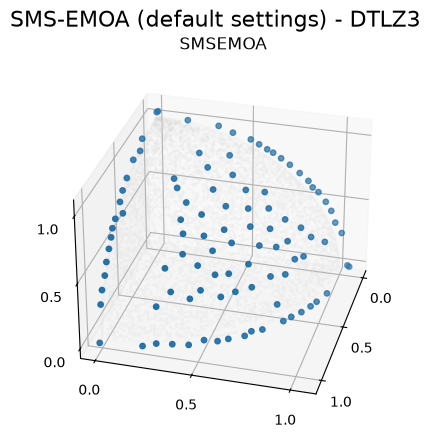

In [10]:
plot_front = Plot(
    title=f"SMS-EMOA (default settings) - {problem.name()}",
    reference_front=reference_front,
    axis_labels=["f1", "f2", "f3"],
)
plot_front.plot(front, label=algorithm.get_name())


In [11]:
report_indicators(front, reference_front, reference_point=[1, 1, 1])

Front size:        100
Hypervolume:       0.3582
IGD+:              0.0572
Additive epsilon:  0.0833


## 4. An unbounded external archive on DTLZ3

Like `build_nsgaii()`, `build_smsemoa()` accepts an `archive=` parameter for free -- both
factories build on the same `EvolutionaryAlgorithm` template, so nothing archive-specific needed
to change to support it. An unbounded archive keeps every non-dominated solution ever evaluated,
so it can grow much larger than the population; `algorithm.result()` does not return the whole
archive, reducing it to the population size via distance-based subset selection first (the same
idea as jMetal Java's `BestSolutionsArchive`) -- see
[`examples/component/nsgaii_unbounded_archive_dtlz2.py`](../examples/component/nsgaii_unbounded_archive_dtlz2.py)
for the same mechanism under NSGA-II.

**The plot below looks worse than section 3's, and that is itself the interesting result.**
DTLZ3's landscape has `3^k - 1` local Pareto-optimal fronts, several of them degenerate: a point
with one objective near zero and the other two large is technically non-dominated (nothing can
beat it on that near-zero objective), even though it is nowhere near the true front. The
unarchived population in section 3 tops out at objective values around 2 (its replacement keeps
every non-dominated front each generation, but only ever *adds* one offspring at a time -- so a
population member that later becomes dominated, once a better solution nearby is found, is
eventually squeezed out by the single-worst-contribution pruning of an ordinary generation). An
unbounded `NonDominatedSolutionsArchive`, by contrast, only ever removes a member when something
strictly dominates it -- and a converged solution near the origin typically does *not* strictly
dominate a degenerate point that is already near-zero in two of its three objectives. Those
degenerate points accumulate in the archive and are never evicted, and `distance_based_subset_selection_robust`
actively favors them when reducing the archive to 100, since it selects for spread, and nothing is
more "spread apart" from the converged cluster than a point with an objective value in the
hundreds. Concretely: the archive's final front has 36 points with an objective above 5 (several
above 100), against zero for section 3's unarchived front.

The indicator values below (HV, IGD+) end up statistically indistinguishable from section 3's
unarchived run despite this -- moocore's indicators are computed against the *whole* front, and
DTLZ3's difficulty already dominates the signal at this evaluation budget either way. The
qualitative story is nonetheless real: unlike NSGA-II, where an external archive materially
improves robustness on problems like ZDT4 because crowding-distance truncation can discard
non-dominated solutions the population later needs, SMS-EMOA's own replacement is already
hypervolume-elitist and self-correcting within the finite population -- so an external archive
here does not just fail to help, it can actively retain solutions the population's own logic was
right to discard. An archive still matters for SMS-EMOA in other settings -- e.g. recovering
solutions across restarts -- just not as a substitute for the population's own convergence
pressure on a landscape like DTLZ3's.


In [12]:
seed = 1
random.seed(seed)

problem = DTLZ3()
reference_front = read_solutions(filename="../resources/reference_fronts/DTLZ3.3D.pf")

archive = NonDominatedSolutionsArchive()
algorithm = build_smsemoa(
    problem,
    population_size=100,
    crossover=SBXCrossover(probability=1.0, distribution_index=20, rng=np.random.default_rng(seed)),
    mutation=PolynomialMutation(
        probability=1.0 / problem.number_of_variables(),
        distribution_index=20,
        rng=np.random.default_rng(seed),
    ),
    termination=TerminationByEvaluations(max_evaluations=40000),
    archive=archive,
    rng=np.random.default_rng(seed),
)
algorithm.run()

front = algorithm.result()  # archive, reduced to population_size via subset selection
print(f"Computing time: {algorithm.total_computing_time:.2f}s")
print(f"Archive size (before reduction): {len(archive.solution_list)}")
print(f"Result size (after reduction):   {len(front)}")


Computing time: 15.88s
Archive size (before reduction): 1078
Result size (after reduction):   100


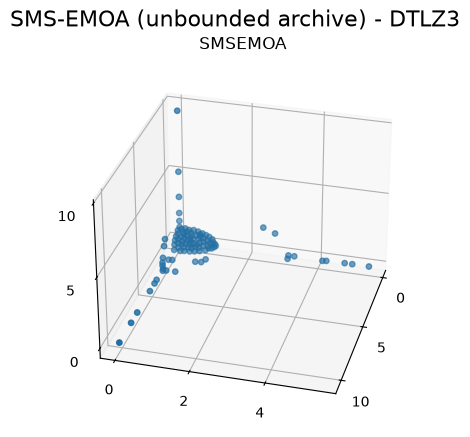

In [13]:
plot_front = Plot(
    title=f"SMS-EMOA (unbounded archive) - {problem.name()}",
    reference_front=reference_front,
    axis_labels=["f1", "f2", "f3"],
)
plot_front.plot(front, label=algorithm.get_name())


In [14]:
report_indicators(front, reference_front, reference_point=[1, 1, 1])

Front size:        100
Hypervolume:       0.3273
IGD+:              0.0674
Additive epsilon:  0.1238


## 5. The observer pattern: watching a front evolve

Every component-based algorithm exposes `algorithm.observable`, the same observer hook the classic
algorithms use. On every generation it notifies registered observers with the exact
`"PROBLEM"`/`"EVALUATIONS"`/`"SOLUTIONS"`/`"COMPUTING_TIME"` keys `AlgorithmState.as_dict()`
produces -- so every observer in `jmetal.util.observer` (`ProgressBarObserver`,
`WriteFrontToFileObserver`, ...) already works against it unchanged.

Here we write a small custom observer instead, to show the pattern directly: it records a copy of
the front's objectives the first time the evaluation count reaches each of a list of checkpoints.
Since SMS-EMOA is steady-state (one offspring evaluated per generation), this notifies -- and can
snapshot -- at every single generation, unlike NSGA-II's generational updates.

ZDT4's initial random population can have `f2` values in the hundreds (its `g()` function is
unbounded away from the optimum, unlike ZDT1's), collapsing to the `[0, 1]` range only in the
last several thousand evaluations -- so each panel below uses its own y-axis scale rather than a
shared one, to keep the early, still-exploring snapshots readable instead of squashed flat by the
final converged scale.


In [15]:
class FrontSnapshotObserver:
    """Collects a copy of the front's objectives at a set of evaluation checkpoints."""

    def __init__(self, checkpoints):
        self.pending_checkpoints = sorted(checkpoints)
        self.snapshots = {}

    def update(self, *args, **kwargs):
        evaluations = kwargs["EVALUATIONS"]
        solutions = kwargs["SOLUTIONS"]

        while self.pending_checkpoints and evaluations >= self.pending_checkpoints[0]:
            checkpoint = self.pending_checkpoints.pop(0)
            self.snapshots[checkpoint] = np.array([s.objectives for s in solutions])


In [16]:
seed = 1
random.seed(seed)

problem = ZDT4()
reference_front = read_solutions(filename="../resources/reference_fronts/ZDT4.pf")
reference_array = np.array([s.objectives for s in reference_front])

checkpoints = [100, 1000, 3000, 6000, 10000, 25000]
snapshot_observer = FrontSnapshotObserver(checkpoints)

algorithm = build_smsemoa(
    problem,
    population_size=100,
    crossover=SBXCrossover(probability=1.0, distribution_index=20, rng=np.random.default_rng(seed)),
    mutation=PolynomialMutation(
        probability=1.0 / problem.number_of_variables(),
        distribution_index=20,
        rng=np.random.default_rng(seed),
    ),
    termination=TerminationByEvaluations(max_evaluations=25000),
    rng=np.random.default_rng(seed),
)
algorithm.observable.register(observer=snapshot_observer)
algorithm.run()

print(f"Collected {len(snapshot_observer.snapshots)} snapshots")


Collected 6 snapshots


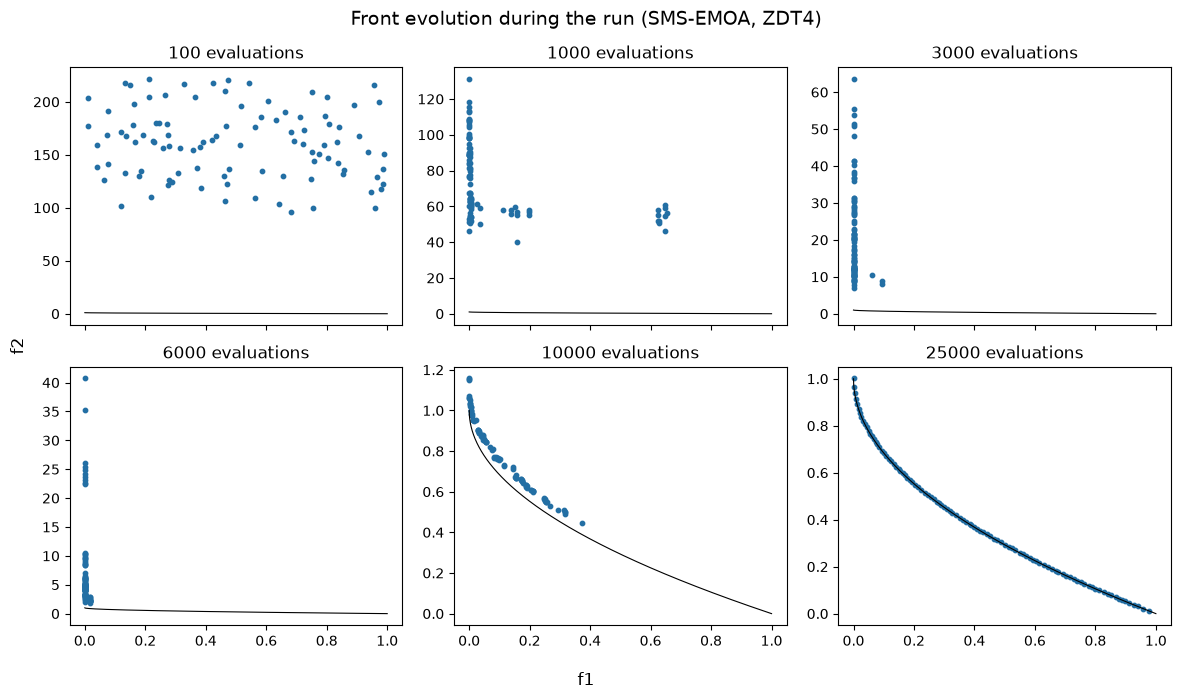

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=False)
fig.suptitle("Front evolution during the run (SMS-EMOA, ZDT4)", fontsize=14)

for ax, checkpoint in zip(axes.flat, checkpoints):
    snapshot = snapshot_observer.snapshots[checkpoint]
    ax.plot(reference_array[:, 0], reference_array[:, 1], color="black", linewidth=0.8)
    ax.scatter(snapshot[:, 0], snapshot[:, 1], color="#236FA4", s=10)
    ax.set_title(f"{checkpoint} evaluations")

fig.supxlabel("f1")
fig.supylabel("f2")
plt.tight_layout()
plt.show()
